# Klädklassificering med Fashion MNIST: en fördjupning i optimerare och learning rate

---

I det här projektet bygger vi en klassificeringsmodell som ska känna igen olika typer av klädesplagg från Fashion MNIST-datasetet. Fokuser ligger inte bara på att få modellen att prestera bra, utan på att undersöka hur olika val påverkar resultatet. Vår fördjupning handlar om optimerare och learning rate, där vi jämför flera varianter för att analysera hur de påverkar modellens träning, accuracy, loss och risk för over- eller underfitting. 

Projektets medlemmar är: 

- Alma
- Jack
- Josefin
- Malin
- Shara
- Vera

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import LearningRateScheduler, EarlyStopping, ReduceLROnPlateau
from tensorflow.keras import regularizers

tf.keras.utils.set_random_seed(42)

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.21.0


## 1 Förstå datan

### Fashion MNIST

Datan som användas i detta projekt är Fashion MNIST, ett inbyggt dataset i Keras som innehåller gråskalebilder av olika klädesplagg. 

Datasetet är färdigt uppdelat i träningsdata och testdata. 

- Träningsdata används för att lära modellen
- Testdata används för att utvärdera modellen efter träning

https://keras.io/api/datasets/fashion_mnist/

In [2]:
# Hämtar Fashion MNIST-datasetet från Keras
fashion_mnist = keras.datasets.fashion_mnist

# Laddar in datasetet. X innehåller bilderna och y innehåller etiketterna/klasserna
(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()

### Datans struktur

Undersöker datans form för att förstå hur många bilder vi har och hur de är strukturerade.

Varje bild är 28x28 pixlar och lagras som en matris med siffror.

In [3]:
# Skriver ut form (shape) på tränings- och testdata för att förstå datans storlek
print('X_train shape:', X_train.shape)
print('y_train shape:', y_train.shape)

print('X_test shape:', X_test.shape)
print('y_test shape:', y_test.shape)

X_train shape: (60000, 28, 28)
y_train shape: (60000,)
X_test shape: (10000, 28, 28)
y_test shape: (10000,)


### Klassnamn

Eftersom etiketter (labels) i datan är siffror (0–9) använder vi en lista med klassnamn för att göra resultaten mer begripliga.

In [4]:
# Lista med klassnamn som motsvarar siffrorna (0–9) i datasetet
class_names = [
    'T-shirt/top',
    'Trouser',
    'Pullover',
    'Dress',
    'Coat',
    'Sandal',
    'Shirt',
    'Sneaker',
    'Bag',
    'Ankle boot'
]

# Skriver ut varje label och motsvarande klassnamn
for i, name in enumerate(class_names):
    print(i, name)

0 T-shirt/top
1 Trouser
2 Pullover
3 Dress
4 Coat
5 Sandal
6 Shirt
7 Sneaker
8 Bag
9 Ankle boot


### Visualisering av en bild

Visar en enskild bild från datasetet för att förstå hur datan ser ut och hur den kopplas till rätt klass.

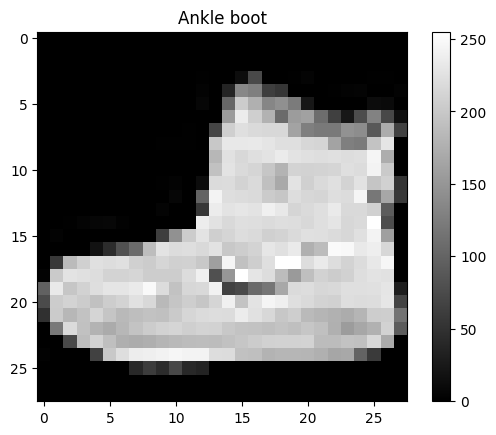

In [5]:
# Visar första bilden i träningsdatan
plt.imshow(X_train[0], cmap='gray')

# Lägger till titel med rätt klassnamn för bilden
plt.title(class_names[y_train[0]])

# Visar färgskalan (pixelvärden)
plt.colorbar()
plt.show()

### Flera exempelbilder

Visar flera bilder samtidigt för att få en bättre känsla för variationen i datasetet och hur olika klasser ser ut.

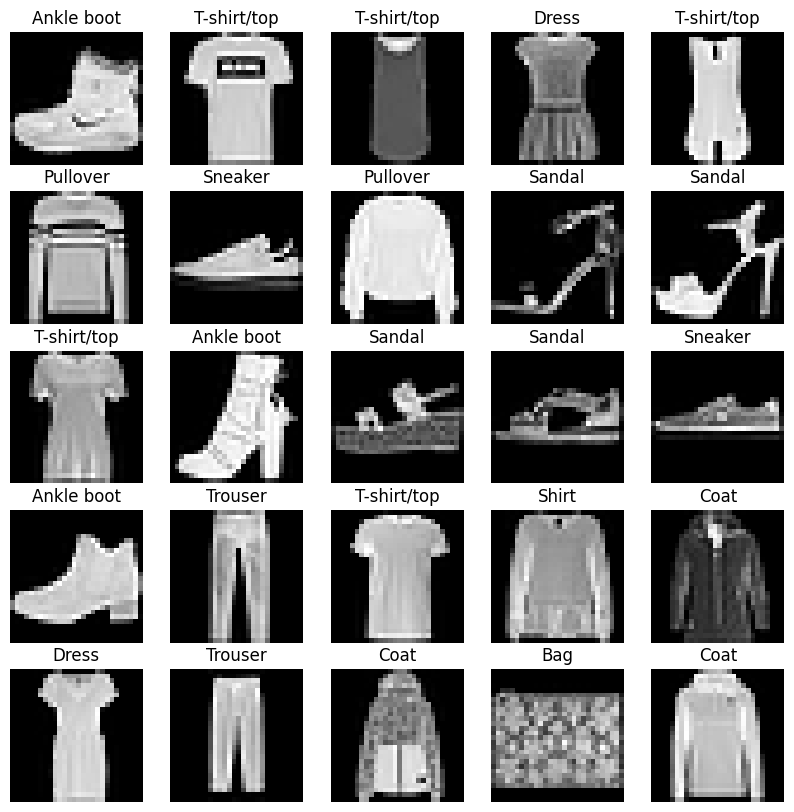

In [6]:
# Visar de första 25 bilderna i träningsdatan i ett 5x5 rutnät,
# tillsammans med respektive klassnamn för att enkelt kunna koppla bild till kategori
plt.figure(figsize=(10,10))

for i in range(25):
    plt.subplot(5,5,i+1)
    plt.imshow(X_train[i], cmap='gray')
    plt.title(class_names[y_train[i]])
    plt.axis('off')

plt.show()

### Klassfördelning

Vi räknar antalet bilder per klass för att undersöka om datasetet är balanserat. Om alla klasser har ungefär lika många bilder behöver vi inte ta särskild hänsyn till klassobalans vid träning och utvärdering av modellen.

In [8]:
# Räknar hur många bilder som finns i varje klass i träningsdatan
unique, counts = np.unique(y_train, return_counts=True)

# Skriver ut antal bilder per klass för att kontrollera datans fördelning
for label, count in zip(unique, counts):
    print(class_names[label], ':', count)

T-shirt/top : 6000
Trouser : 6000
Pullover : 6000
Dress : 6000
Coat : 6000
Sandal : 6000
Shirt : 6000
Sneaker : 6000
Bag : 6000
Ankle boot : 6000


## 2 Dataförberedelse

### Valideringsset

Vi skapar ett valideringsset från träningsdatan för att kunna följa hur modellen presterar på data den inte tränas på. 

På så sätt kan vi upptäcka om modellen börjar överanpassa sig till träningsdatan. 

Vi använder 20 % av träningsdatan som valideringsdata eftersom det ger tillräckligt mycket data för validering samtidigt som majoriteten fortfarande används för träning.

In [ ]:
# Skapa valideringsset
X_train, X_val, y_train, y_val = train_test_split(
    X_train,
    y_train,
    test_size=0.20,
    random_state=42,
    stratify=y_train
)

# Kontrollera att det stämmer
print("X_train:", X_train.shape)
print("X_val:", X_val.shape)
print("y_train:", y_train.shape)
print("y_val:", y_val.shape)

X_train: (48000, 28, 28)
X_val: (12000, 28, 28)
y_train: (48000,)
y_val: (12000,)


### Lägga till kanaldimension

Fashion MNIST-bilderna är ju som sagt gråskalebilder och saknar därför en tydlig kanaldimension. 

Eftersom CNN-lager förväntar sig bilder i formatet höjd, bredd och kanal lägger vi till en extra dimension. 

Bilderna får då formen (28, 28, 1) där 1 betyder färgkanal (1 = gråskala, 3 = RGB/färgbild)

In [11]:
# Lägga till kanaldimension till X_train
X_train = X_train[..., np.newaxis]
X_val = X_val[..., np.newaxis]
X_test = X_test[..., np.newaxis]

print("X_train shape efter kanal-dimension:", X_train.shape)
print("X_val shape efter kanal-dimension:", X_val.shape)
print("X_test shape efter kanal-dimension:", X_test.shape)

X_train shape efter kanal-dimension: (48000, 28, 28, 1)
X_val shape efter kanal-dimension: (12000, 28, 28, 1)
X_test shape efter kanal-dimension: (10000, 28, 28, 1)


### Normalisering av pixelvärden

Bildernas pixelvärden ligger från början mellan 0 och 255. 

Genom att dela värdena med 255 normaliseras datan till intervallet 0-1, vilket ofta gör träningen mer stabil och effektiv för neurala nätverk.

In [12]:
# Normaliserar pixelvärden från 0-255 till 0-1
X_train = X_train.astype("float32") / 255.0
X_val = X_val.astype("float32") / 255.0
X_test_norm = X_test.astype("float32") / 255.0

# Kontrollerar att normaliseringen fungerade
print("X_train min/max:", X_train.min(), X_train.max())
print("X_val min/max:", X_val.min(), X_val.max())
print("X_test min/max:", X_test_norm.min(), X_test_norm.max())
print("X_train shape:", X_train.shape)

X_train min/max: 0.0 1.0
X_val min/max: 0.0 1.0
X_test min/max: 0.0 1.0
X_train shape: (48000, 28, 28, 1)


## 3 Bygga en första modell

Vi valde att börja med en enkel CNN-modell som basmodell eftersom datasetet består av bilddata. 

Convolution-lagret används för att hitta mönster i bilderna, medan MaxPooling minskar datamängden och gör modellen mer effektiv.

Dense-lagren används sedan för att klassificera bilden till en av de 10 klasserna. 

In [13]:
# Basmodell

baseline_model = keras.Sequential([
    layers.Input(shape=(28, 28, 1)),
    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(10, activation='softmax')
])

## 4 Träna modellen

Föregående steg definierar endast modellen struktur. Inställningar för optimizer, learning rate och batch size anges i funktionen model_compile_and_fit, där modellen kompileras och tränas.

På så sätt kan vi återanvända samma modellstruktur men enkelt jämföra olika träningsinställningar. 

Som basinställningar valde vi Adam som optimizer, learning rate 0,001, batch size 32 och 20 epoker. 

Dessa värden används som en stabil utgångspunkt innan vi testar andra varianter på optimizer och learning rate.

Adam är en vanligt använd optimizer som ofta fungerar bra som standardval. Learning rate 0,001 är ett vanligt startvärde för Adam, medan batch size 32 ger en rimlig balans mellan stabil träning och effektivitet. 

Vi valde 20 epoker för att modellen skulle hinna lära sig mönster i datan, samtidigt som vi kunde följa om den började visa tecken på overfitting. Vi använder även Early Stopping för att avbryta träningen om valideringsförslusten (val_loss) inte förbättras efter 3 epoker. Detta minskar risken för overfitting och gör att modellen återgår till de bästa vikterna från träningen. 

Modellen kompileras med loss-funktionen sparse_categorical_crossentropy eftersom uppgiften är en flerkategoriklassificering där varje bild tillhör en av 10 klasser. Etiketterna är heltal, 0-9, vilket gör att vi kan anvnda "sparse"-varianten utan att först omvandla etiketterna med one-hot encoding.

https://keras.io/api/optimizers/adam/

Epoch 1/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8546 - loss: 0.4088 - val_accuracy: 0.8845 - val_loss: 0.3190
Epoch 2/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9013 - loss: 0.2745 - val_accuracy: 0.8961 - val_loss: 0.2853
Epoch 3/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9173 - loss: 0.2269 - val_accuracy: 0.9063 - val_loss: 0.2667
Epoch 4/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9316 - loss: 0.1885 - val_accuracy: 0.9078 - val_loss: 0.2641
Epoch 5/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9438 - loss: 0.1570 - val_accuracy: 0.9084 - val_loss: 0.2745
Epoch 6/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9539 - loss: 0.1297 - val_accuracy: 0.9057 - val_loss: 0.2938
Epoch 7/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9617 - loss: 0.1086 - val_accuracy: 0.9063 - val_loss: 0.3134

Resultat för Basmodell:
Antal epoker:        7
Train accuracy:      0.9438
Train loss:   

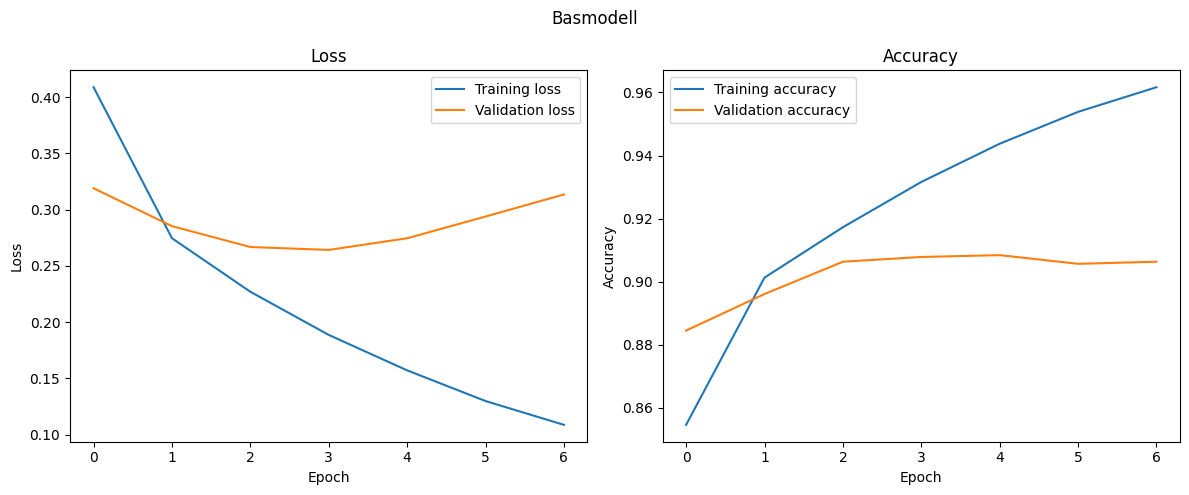

     name  train_accuracy  train_loss  validation_accuracy  validation_loss  epochs_trained  learning_rate  training_time
Basmodell         0.94375    0.157032             0.908417         0.274462               7          0.001      22.623337


In [ ]:
# Importerar egna hjälpfunktioner för träning och visualisering av resultat
from utils_final import model_compile_and_fit
from utils_final import plot_history

# Skapar en lista för att spara resultatet i
results = []

# Kompilerar och tränar basmodellen
model_bas, h_bas, r_bas = model_compile_and_fit(baseline_model, X_train, y_train, X_val, y_val, name="Basmodell")
results.append(r_bas)

print(pd.DataFrame(results).to_string(index=False))

### Analys av basmodell

Resultatet visar att basmodellen lär sig snabbt på träningsdatan, efter training_loss minskar och training_accuracy ökar tydligt. 

Valideringsresultatet förbättras i början, men planar sedan ut runt 90 % accuracy. 

Efter några epoker börjar validation_loss öka samtidigt som training_loss fortsätter minska, vilket tyder på overfitting. 

Early Stopping avbryter träningen efter 7 epoker, eftersom modellen inte längre förbättras på valideringsdatan.

Resulatet är 94 % training_accuracy och 90 % validation_accuracy. 

## 5 Testa och förbättra modellen

Basmodellen utökades först med ett till Conv2D-lager.

In [ ]:
# Förbättrad modell med ett till Conv2D-block

improved_model = keras.Sequential([
    layers.Input(shape=(28, 28, 1)),
    layers.Conv2D(32, (3, 3), activation="relu", padding="same"),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation="relu", padding="same"),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(128, activation="relu",),
    layers.Dense(10, activation="softmax")
])

In [ ]:
# Compilerar och tränar förbättrad modell

model_imp, h_imp, r_imp = model_compile_and_fit(improved_model, X_train, y_train, X_val, y_val, name="Förbättrad modell")
results.extend([r_imp])

print(pd.DataFrame(results).to_string(index=False))

### Analys av förbättrad modell

Det extra Conv2D-lagret ger en något bättre accuracy på validationdatan på 0,913 men kurvorna uppvisar samma mönster av överanpassning som i basmodellen.  

För att minska överanpassningen testades att lägga till dropout.

In [ ]:
# Ytterligare förbättrad modell med dropout

improved_model2 = keras.Sequential([
    layers.Input(shape=(28, 28, 1)),
    layers.Conv2D(32, (3, 3), activation="relu", padding="same"),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation="relu", padding="same"),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(128, activation="relu",),
    layers.Dropout(0.3),
    layers.Dense(10, activation="softmax")
])

In [ ]:
# Compilerar och tränar förbättrad modell 2

model_imp2, h_imp2, r_imp2 = model_compile_and_fit(improved_model2, X_train, y_train, X_val, y_val, name="Förbättrad modell 2")
results.append(r_imp2)

print(pd.DataFrame(results).to_string(index=False))

### Analys av förbättrad modell 2

Med dropout så fås lägre accuracy på trainingdatan 0,938 jämfört med 0,959 men gapet mot accuracy på valideringsdatan är mindre. Loss på valideringsdatan har minskat från 0,302 till 0,261. Tränings- och valideringskurvorna följer varandra bättre. Denna modell generaliserar bättre än de tidigare.

## 6 Fördjupning i fokusområde optimerare och inlärningshastighet

Tre olika optimerare testas med tre olika inlärningshastigheter.

### Adam med LR 0,0001, 0,001 och 0,01

In [ ]:
# Experiment med Adam och olika inlärningshastigheter

model_adam_low, h_adam_low, r_adam_low = model_compile_and_fit(improved_model2, X_train, y_train, X_val, y_val, name="Adam LR 0.0001", optimizer="adam", learning_rate=0.0001)
model_adam, h_adam, r_adam = model_compile_and_fit(improved_model2, X_train, y_train, X_val, y_val, name="Adam LR 0.001", optimizer="adam", learning_rate=0.001)
model_adam_high, h_adam_high, r_adam_high = model_compile_and_fit(improved_model2, X_train, y_train, X_val, y_val, name="Adam LR 0.01", optimizer="adam", learning_rate=0.01)
results.extend([r_adam_low, r_adam, r_adam_high])

print(pd.DataFrame(results).to_string(index=False))

Kommentar

### Experiment SGD med LR 0,0001, 0,001 och 0,01

In [ ]:
# Experiment med SGD och olika inlärningshastigheter

model_sgd_low, h_sgd_low, r_sgd_low = model_compile_and_fit(improved_model2, X_train, y_train, X_val, y_val, name="SGD LR 0.0001", optimizer="sgd", learning_rate=0.0001)
model_sgd, h_sgd, r_sgd = model_compile_and_fit(improved_model2, X_train, y_train, X_val, y_val, name="SGD LR 0.001", optimizer="sgd", learning_rate=0.001)
model_sgd_high, h_sgd_high, r_sgd_high = model_compile_and_fit(improved_model2, X_train, y_train, X_val, y_val, name="SGD LR 0.01", optimizer="sgd", learning_rate=0.01)
results.extend([r_sgd_low, r_sgd, r_sgd_high])

print(pd.DataFrame(results).to_string(index=False))

Kommentar

### Experiment RMSprop med LR 0,0001, 0,001 och 0,01

In [ ]:
# Experiment med RMSprop och olika inlärningshastigheter

model_rms_low, h_rms_low, r_rms_low = model_compile_and_fit(improved_model2, X_train, y_train, X_val, y_val, name="RMSprop LR 0.0001", optimizer="rmsprop", learning_rate=0.0001)
model_rms, h_rms, r_rms = model_compile_and_fit(improved_model2, X_train, y_train, X_val, y_val, name="RMSprop LR 0.001", optimizer="rmsprop", learning_rate=0.001)
model_rms_high, h_rms_high, r_rms_high = model_compile_and_fit(improved_model2, X_train, y_train, X_val, y_val, name="RMSprop LR 0.01", optimizer="rmsprop", learning_rate=0.01)
results.extend([r_rms_low, r_rms, r_rms_high])

print(pd.DataFrame(results).to_string(index=False))

Kommentar

In [ ]:
display(pd.DataFrame(results)
    .sort_values("validation_accuracy", ascending=False)
    .style.format({
    "train_accuracy":      "{:.4f}",
    "train_loss":          "{:.4f}",
    "validation_accuracy": "{:.4f}",
    "validation_loss":     "{:.4f}",
    "epochs_trained":      "{:.0f}",
    "training_time":       "{:.1f}s"
}).highlight_max(subset=["validation_accuracy"], color="darkgreen")
  .highlight_min(subset=["validation_loss"], color="darkblue")
  .set_caption("Sammanfattning av alla experiment")
  .set_table_styles([{"selector": "caption", "props": [("font-size", "16px"), ("font-weight", "bold")]}]))

In [ ]:
# Sparar bästa modellen
best_model = model_adam
best_model.save("best_model.keras")

In [ ]:
# Testar bästa modellen på testdatan

best_model = keras.models.load_model("best_model.keras")

test_loss, test_accuracy = best_model.evaluate(X_test_norm, y_test, verbose=0)

print(test_loss)
print(test_accuracy)

# Gör nåt snyggt av det. DF jämförelse

## 7 Analys och slutsatser för fokusområde optimerare och inlärningshastighet

Adam:   
Adam med låg inlärningshastighet 0,0001, har högst accuracy på valideringsdata och tränings- och valideringskurvorna följer varandra väl. Modellen generaliserar bäst av de tre men är den som använder flest epoker och tar längst tid. Adam med hög inlärningshastighet har instabila kutvor och ser ut att hoppa över bra minima. Adam med mellanhastigheten som är en vanlig standard börjar överanpassa vid epok 3 men tar mindre än halva tiden än den med låg inlärningshastighet och kan vara en bra kompromiss.

SGD:   
Med låg inlärningshastighet når SGD inte upp i så hög accuracy på valideringsdatan, 0,712. Kurvorna visar att modellen inte har lärt sig klart. Med högre inlärningshastighet hinner SGD-modellerna lära sig mer och accuracy på valideringsdatan ökar men ligger fortfarande bland de lägre och under basmodellens. 

RMSprop:    
RMSprop visar ett liknande resultat som Adam där tränings- och valideringskurvorna följer varandra väl i den lägsta inlärningshastiheten medan bästa accuracy på valideringsdatan får i modellen med inlärningshastigheten 0,001. 

**Slutsats**  
SGD är den enklaste optimeraren som bara tar steg baserat på aktuell gradient men den tar inte hänsyn till tidigare steg och blir därför långsammre än de övriga. RMSprop kan anpassa steglängden utifrån tidigare gradienter vilket gör den snabbare. Adam kan också anpassa steglängden men den kan dessutom minnas i vilken riktning stegen tagits och det gör den snabbare att konvergera än SGD och RMSprop.  

Valet av inlärningshastighet påverkar optimerarna olika. SGD är känsligast eftersom den saknar adaptiv anpassning och en för låg inlärningshastighet gör att modellen inte hinner lära sig tillräckligt medan en högre krävs för att nå acceptabel accuracy. RMSprop och Adam är mer förlåtande tack vare sin adaptiva steglängd, men en för hög inlärningshastighet ger instabila kurvor för båda. Generellt gäller att lägre inlärningshastighet ger jämnare kurvor och bättre generalisering men kräver fler epoker, medan högre inlärningshastighet konvergerar snabbare men riskerar att hoppa över bra minima.
